In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

df_master = pd.read_csv('../outputs/tables/master_df_final.csv')
print("Ready:", df_master.shape)

Ready: (30, 14)


In [13]:
#evaluate data frame before plotting
print(df_master.head())
print(df_master.dtypes)
print(df_master.columns.tolist())

  state_or_region  year price_sector      price renewable_sector  \
0         Arizona  2025   commercial  12.397500       commercial   
1      California  2025   commercial  26.192500       commercial   
2        Colorado  2025   commercial  12.440000       commercial   
3     Connecticut  2025   commercial  23.155833       commercial   
4        Delaware  2025   commercial  12.648333       commercial   

   renewable_generation total_generation_sector  total_generation  \
0                  20.0              commercial             148.0   
1                 858.0              commercial            2276.0   
2                   8.0              commercial              23.0   
3                  25.0              commercial             302.0   
4                   8.0              commercial               8.0   

     dc_sector  data_center_facility_count  data_center_estimated_power_mw  \
0  all_sectors                          20                          891.46   
1  all_sectors      

In [14]:
df_master.info()
print(df_master.shape)
df_master.describe()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state_or_region                 30 non-null     str    
 1   year                            30 non-null     int64  
 2   price_sector                    30 non-null     str    
 3   price                           30 non-null     float64
 4   renewable_sector                30 non-null     str    
 5   renewable_generation            30 non-null     float64
 6   total_generation_sector         30 non-null     str    
 7   total_generation                30 non-null     float64
 8   dc_sector                       30 non-null     str    
 9   data_center_facility_count      30 non-null     int64  
 10  data_center_estimated_power_mw  30 non-null     float64
 11  data_center_selected_power_mw   30 non-null     float64
 12  renewable_share                 30 non-null     f

,year,price,renewable_generation,total_generation,data_center_facility_count,data_center_estimated_power_mw,data_center_selected_power_mw,renewable_share,total_wd_mgd
count,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2025.0,13.124278,138.800000,481.433333,6.366667,252.778667,341.147967,0.353167,2042.945108
std,0.0,4.540858,220.938188,613.535862,8.965387,387.461424,514.724201,0.290912,2135.342409
min,2025.0,8.639167,-1.000000,-3.000000,1.000000,0.600000,0.500000,0.000000,2.027209
25%,2025.0,10.341250,9.500000,83.000000,1.000000,34.367500,34.000000,0.079464,75.630890
50%,2025.0,11.910833,31.000000,236.500000,3.000000,98.445000,101.250000,0.358732,1673.521933
75%,2025.0,13.676458,141.500000,697.500000,6.500000,251.965000,377.735000,0.484523,3308.933418
max,2025.0,26.192500,858.000000,2276.000000,40.000000,1812.730000,2078.910000,1.000000,7904.488835


In [3]:
#Data center demand + total generation, renewable share, and electricity price correlation
cols_1= ['data_center_selected_power_mw', 'renewable_share', 'price', 'total_generation']
df_matrix1= df_master[cols_1]
corr_1= df_matrix1.corr()
print(corr_1)

                               data_center_selected_power_mw  renewable_share  \
data_center_selected_power_mw                       1.000000        -0.174433   
renewable_share                                    -0.174433         1.000000   
price                                              -0.253041        -0.193043   
total_generation                                    0.059199        -0.180984   

                                  price  total_generation  
data_center_selected_power_mw -0.253041          0.059199  
renewable_share               -0.193043         -0.180984  
price                          1.000000          0.725941  
total_generation               0.725941          1.000000  


Finding 1 — data_center_selected_power_mw vs price: -0.25
A negative correlation was observed between data center selected power capacity and electricity price. I would expect these to be positively correlated — higher demand typically drives up price — however this may reflect deliberate site selection by data center operators who seek out states with cheap, abundant power. In reality, growing data center demand is placing upward pressure on prices in many markets, which this small sample may not capture.
With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn.



Finding 2 — data_center_selected_power_mw vs renewable_share: -0.17
Data center selected power and renewable share show a weak negative correlation. Intuitively I would expect states with higher DC demand to invest more heavily in renewables to bridge the supply gap cheaply, but this sample suggests the opposite — states with higher sampled demand tend to have lower renewable share. This may reflect that data centers are currently siting in fossil-fuel dominated grids where power is cheapest.
With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn.



Finding 3 — price vs total_generation: +0.73
The strongest relationship in this matrix. Rather than higher supply driving lower prices as economics might suggest, both variables appear to be driven by a confounding variable — state size. Larger states with greater economic activity and population have both higher total generation and higher electricity prices, as demand is placing strain on the grid that supply is struggling to meet.
With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn.

In [15]:
#Using plotly to show state as a third qualitative variable in Total Power Generation vs Electricity Price scatter plot. 
import plotly.express as px
fig = px.scatter(df_master, x = 'total_generation', y='price', hover_name = 'state_or_region', color = 'state_or_region', 
#manually assign labels 
             labels = {'total_generation' : 'Total Power Generation (MW)', 'price' : 'Electricity Price (cents/MWh)', 'state_or_region': 'State'})
fig.update_xaxes(title_text='Total Power Generation (MW)')
fig.update_yaxes(title_text='Electricity Price (cents/MWh)')
#adjust marker size for better visibility
fig.update_traces(marker_size=15)
fig.show()
# this plot is experimental and the color map for states is not ideal or easy to read. The next plot utilizes plotly express to show state names by hovering, while also introducing a third variable. 

In [ ]:
#Using plotly express to add a qualitative variable as state in Total Power Generation vs Electricity Price, with thermelectric water withdrawals by size 
import plotly.express as px
fig = px.scatter(df_master, x = 'total_generation', y='price', hover_name = 'state_or_region', size = 'total_wd_mgd', size_max = 30, 
#manually assign hover labels 
labels = {'total_generation' : 'Total Power Generation (MWh)', 'price' : 'Electricity Price (cents/MWh)','state_or_region' : 'State', 'total_wd_mgd' : 'Total Thermoelectric Water Withdrawals (mg/d)'}, 
title = 'Total Power Generation vs Electricity Price with Total Thermoelectric Water Withdrawals as Size')
#adjust marker size for better visibility
fig.write_html('../outputs/figures/Scatter_plot_1.html')
fig.show()

Finding 3 — price vs total_generation: +0.73
The strongest relationship in this matrix. Rather than higher supply driving lower prices as economics might suggest, both variables appear to be driven by a confounding variable — state size. Larger states with greater economic activity and population have both higher total generation and higher electricity prices, as demand is placing strain on the grid that supply is struggling to meet. Thermoelectric withdraw doesn't seem to show a strong pattern in relation to electricity price or total power generation. For example, New Jersey shows a higher total power generation than Texas and Florida, which doesn't add up, because Texas and Florida are among the top three highest electricity producers in The United States. Even given that error, Texas and Flrodia are known to use more traditional "once-through" water cooling systems as opposed to New Jersey increasingly utilizing closed-loop water cooling systems. Furthermore, New Jersey does exhibit a higher ratio of energy production to thermoelectric water withdrawals, most likely due to its higher reliance on nuclear and solar energy sources, which combined require less water overall.
With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn. 

In [9]:
cols_2= ['total_wd_mgd', 'renewable_share', 'data_center_selected_power_mw', 'total_generation']
df_matrix2= df_master[cols_2]
corr_2= df_matrix2.corr()
print(corr_2)

                               total_wd_mgd  renewable_share  \
total_wd_mgd                       1.000000        -0.361748   
renewable_share                   -0.361748         1.000000   
data_center_selected_power_mw      0.358009        -0.174433   
total_generation                   0.375764        -0.180984   

                               data_center_selected_power_mw  total_generation  
total_wd_mgd                                        0.358009          0.375764  
renewable_share                                    -0.174433         -0.180984  
data_center_selected_power_mw                       1.000000          0.059199  
total_generation                                    0.059199          1.000000  


Finding 1 — total_wd_mgd vs renewable_share: -0.36

States with a higher renewable energy share tend to have lower thermoelectric water withdrawals. This is consistent with the known water intensity of thermal generation — coal, natural gas, and nuclear plants require significant cooling water, while solar and wind do not. This is one of the stronger relationships in the dataset (r = -0.36) and aligns with established energy-water nexus literature. With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn.

Finding 2 — total_wd_mgd vs data_center_selected_power_mw: +0.36

States with higher sampled data center demand show slightly higher thermoelectric water withdrawals. This likely reflects co-location in large industrial states with fossil-fuel heavy grids rather than a direct causal link. With a larger sample this relationship would be worth examining further. With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn.

Finding 3 — total_wd_mgd vs total_generation: +0.38

Total water withdrawal correlates positively with total generation, consistent with the expectation that larger electricity systems — which rely more heavily on thermal generation — withdraw more water for cooling. With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn.


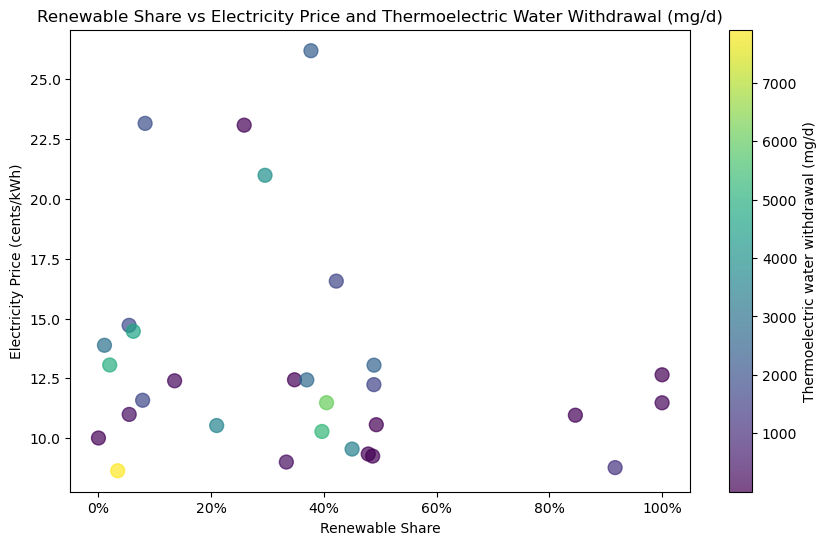

In [8]:
#scatter visualizations, using seaborn for a third numeric variable (total_wd_mgd) as color
plt.figure(figsize=(10, 6))
x = df_master['renewable_share']
y = df_master['price']
z = df_master['total_wd_mgd']
scat = plt.scatter(x, y, s = 100, c=z, cmap = 'viridis',alpha = 0.7)
plt.colorbar(scat, label = 'Thermoelectric water withdrawal (mg/d)')
plt.xlabel('Renewable Share')
plt.ylabel('Electricity Price (cents/kWh)')
# format x-axis as percentage
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Renewable Share vs Electricity Price and Thermoelectric Water Withdrawal (mg/d)')
plt.savefig('../outputs/figures/Scatter_plot_2.png', dpi=300, bbox_inches='tight')
plt.show()

Finding 1 — total_wd_mgd vs renewable_share: -0.36 
renewable_share vs price: -.193
I would expect states with higher renewable share to have a stronger correlation with lower electricity price because renewables tend to have a lower levelized cost of electricity, but the plot doesn't show that pattern. If the correlation were run against all fifty states, maybe there would be a higher correlation. States with a higher renewable energy share tend to have lower thermoelectric water withdrawals. This is consistent with the known water intensity of thermal generation — coal, natural gas, and nuclear plants require significant cooling water, while solar and wind do not. This is one of the stronger relationships in the dataset (r = -0.36) and aligns with established energy-water nexus literature, although it is not a particularly strong correlation.
With only 30 observations this relationship is exploratory only and no realistic conclusions can be drawn.

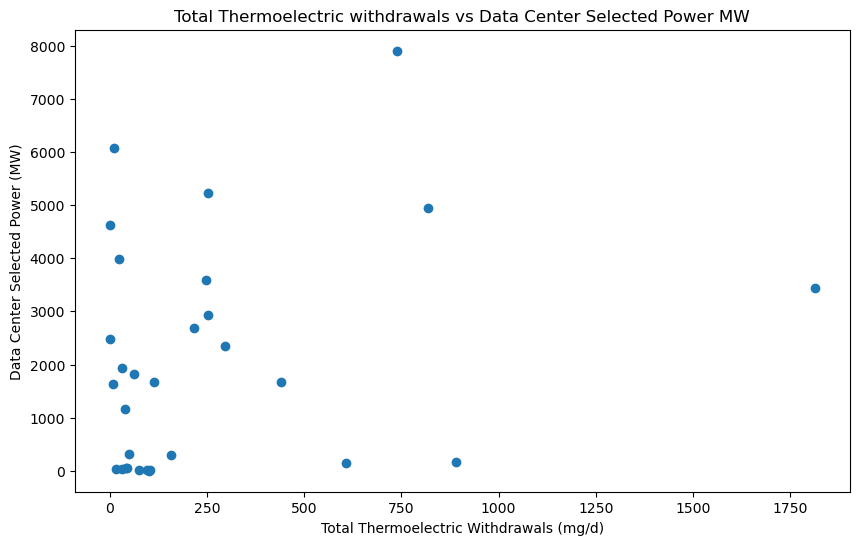

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df_master['data_center_estimated_power_mw'], df_master['total_wd_mgd'], alpha=1)
plt.xlabel('Total Thermoelectric Withdrawals (mg/d)')
plt.ylabel('Data Center Selected Power (MW)')
plt.title('Total Thermoelectric withdrawals vs Data Center Selected Power MW')
plt.show()

In [9]:
import plotly.express as px
fig = px.scatter(df_master, x ='total_wd_mgd', y = 'data_center_selected_power_mw', hover_name = 'state_or_region', 
labels = { 'total_wd_mgd' : 'Total Thermoelectric Withdrawals (mg/d)', 'data_center_selected_power_mw' : 'Data Center Power Capacity(MW)', 'renewable_share' : 'Renewable Share' }, size = 'renewable_share', size_max = 20,
title = 'Total Thermoelectric Withdrawals (mg/d) vs Data Center Power Capacity (MW) with Renewable Share as Size')
fig.write_html('../outputs/figures/Scatter_plot_3.html')    
fig.show()

Data Center Selected Power Capacity (MW) vs Total Thermoelectric Water Withdrawals (mg/d): .358

There is a positive correlation between Data Center Power Capacity (MW) and Total Thermoelectric Water Withdrawals, although not a particularly strong one. Larger Data Centers that require more power in states with lower renewable share would presumably have less total thermoelectric water withdrawals. Florida has 40% renewable share yet has the second largest thermoelelectric water withdrawal overall. North Carolina also has roughly 40% renewable share yet is the third largest consumer of thermoelectric water withdrawals as well. Even though a state has substantial renewable share, they could still be operating large natural gas turbines to meet the increased power demand of data centers while the renewable generation portion is serving residential and commercial areas of the grid. This would explain the lack of correlation, because power grid feed locations are important, and must be intentional. 